# 🔬 So Sánh Các Phương Pháp Clustering - Carbon-24

**Mục tiêu:** Đánh giá và so sánh hiệu suất của 4 phương pháp clustering:
1. **K-means** - Phân cụm dựa trên centroid
2. **GMM (Gaussian Mixture Model)** - Phân cụm xác suất
3. **Hierarchical** - Phân cụm phân cấp
4. **HDBSCAN** - Phân cụm dựa trên mật độ

**Dataset:** 10,153 cấu trúc Carbon-24

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Metrics
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print(' Libraries imported successfully!')

 Libraries imported successfully!


##  1. Load Clustering Results

In [2]:
# Load results from each method
results = {}

# 1. K-means
print(' Loading K-means results...')
try:
    kmeans_df = pd.read_csv('carbon24_kmeans_results/carbon24_clustered.csv')
    with open('carbon24_kmeans_results/clustering_report.json', 'r') as f:
        kmeans_report = json.load(f)
    results['K-means'] = {
        'data': kmeans_df,
        'report': kmeans_report,
        'n_clusters': len(kmeans_df['cluster'].unique())
    }
    print(f'   K-means: {len(kmeans_df)} samples, {results["K-means"]["n_clusters"]} clusters')
except Exception as e:
    print(f'   Error loading K-means: {e}')

# 2. GMM
print('\n Loading GMM results...')
try:
    # Try to find GMM results
    gmm_files = list(Path('carbon24_gmm_results/results').glob('*.csv'))
    if gmm_files:
        gmm_df = pd.read_csv(gmm_files[0])
        results['GMM'] = {
            'data': gmm_df,
            'n_clusters': len(gmm_df['GMM_Cluster'].unique()) if 'GMM_Cluster' in gmm_df.columns else 'N/A'
        }
        print(f'   GMM: {len(gmm_df)} samples, {results["GMM"]["n_clusters"]} clusters')
    else:
        print('    GMM results not found in expected location')
except Exception as e:
    print(f'   Error loading GMM: {e}')

# 3. Hierarchical
print('\n Loading Hierarchical results...')
try:
    hier_files = list(Path('carbon24_hierarchical_baseline/results').glob('*.csv'))
    if hier_files:
        hier_df = pd.read_csv(hier_files[0])
        results['Hierarchical'] = {
            'data': hier_df,
            'n_clusters': len(hier_df['cluster_hierarchical'].unique()) if 'cluster_hierarchical' in hier_df.columns else 'N/A'
        }
        print(f'   Hierarchical: {len(hier_df)} samples, {results["Hierarchical"]["n_clusters"]} clusters')
    else:
        print('    Hierarchical results not found')
except Exception as e:
    print(f'   Error loading Hierarchical: {e}')

# 4. HDBSCAN
print('\n Loading HDBSCAN results...')
try:
    hdbscan_df = pd.read_csv('hdbscan_phuc/hdbscan_results.csv')
    hdbscan_profile = pd.read_csv('hdbscan_phuc/hdbscan_cluster_profile.csv')
    
    # Rename hdbscan_cluster to cluster for consistency
    if 'hdbscan_cluster' in hdbscan_df.columns:
        hdbscan_df = hdbscan_df.rename(columns={'hdbscan_cluster': 'cluster'})
    
    results['HDBSCAN'] = {
        'data': hdbscan_df,
        'profile': hdbscan_profile,
        'n_clusters': len(hdbscan_df['cluster'].unique()) - (1 if -1 in hdbscan_df['cluster'].values else 0),
        'n_noise': (hdbscan_df['cluster'] == -1).sum() if 'cluster' in hdbscan_df.columns else 0
    }
    print(f'   HDBSCAN: {len(hdbscan_df)} samples, {results["HDBSCAN"]["n_clusters"]} clusters')
    print(f'     Noise points: {results["HDBSCAN"]["n_noise"]}')
except Exception as e:
    print(f'   Error loading HDBSCAN: {e}')

print(f'\n Loaded {len(results)} clustering methods')

 Loading K-means results...
   K-means: 10153 samples, 3 clusters

 Loading GMM results...
   GMM: 10153 samples, 10 clusters

 Loading Hierarchical results...
   Hierarchical: 10153 samples, 3 clusters

 Loading HDBSCAN results...
   HDBSCAN: 10153 samples, 3 clusters
     Noise points: 786

 Loaded 4 clustering methods


## 2. Overview Comparison

In [3]:
# Create overview table
overview_data = []

for method, data in results.items():
    row = {
        'Method': method,
        'Samples': len(data['data']),
        'Clusters': data['n_clusters']
    }
    
    if method == 'HDBSCAN':
        row['Noise Points'] = data['n_noise']
        row['Noise %'] = f"{data['n_noise']/len(data['data'])*100:.2f}%"
    else:
        row['Noise Points'] = 0
        row['Noise %'] = '0.00%'
    
    overview_data.append(row)

overview_df = pd.DataFrame(overview_data)

print('=' * 80)
print('CLUSTERING METHODS OVERVIEW')
print('=' * 80)
print(overview_df.to_string(index=False))
print('=' * 80)

CLUSTERING METHODS OVERVIEW
      Method  Samples  Clusters  Noise Points Noise %
     K-means    10153         3             0   0.00%
         GMM    10153        10             0   0.00%
Hierarchical    10153         3             0   0.00%
     HDBSCAN    10153         3           786   7.74%


##  3. Cluster Distribution Analysis

In [4]:
# Analyze cluster distribution for each method
print('=' * 80)
print(' CLUSTER DISTRIBUTION')
print('=' * 80)

for method, data in results.items():
    print(f'\n{method}:')
    print('-' * 60)
    
    # Xác định tên cột cluster cho từng phương pháp
    cluster_col = None
    if method == 'GMM' and 'GMM_Cluster' in data['data'].columns:
        cluster_col = 'GMM_Cluster'
    elif method == 'Hierarchical' and 'cluster_hierarchical' in data['data'].columns:
        cluster_col = 'cluster_hierarchical'
    elif 'cluster' in data['data'].columns:
        cluster_col = 'cluster'
    
    if cluster_col:
        cluster_counts = data['data'][cluster_col].value_counts().sort_index()
        
        for cluster_id, count in cluster_counts.items():
            percentage = count / len(data['data']) * 100
            if cluster_id == -1:
                print(f'  Noise: {count:,} ({percentage:.2f}%)')
            else:
                print(f'  Cluster {cluster_id}: {count:,} ({percentage:.2f}%)')
    else:
        print('   No cluster column found')

 CLUSTER DISTRIBUTION

K-means:
------------------------------------------------------------
  Cluster 0: 3,402 (33.51%)
  Cluster 1: 2,228 (21.94%)
  Cluster 2: 4,523 (44.55%)

GMM:
------------------------------------------------------------
  Cluster 0: 955 (9.41%)
  Cluster 1: 194 (1.91%)
  Cluster 2: 847 (8.34%)
  Cluster 3: 3,226 (31.77%)
  Cluster 4: 823 (8.11%)
  Cluster 5: 24 (0.24%)
  Cluster 6: 1,096 (10.79%)
  Cluster 7: 35 (0.34%)
  Cluster 8: 1,383 (13.62%)
  Cluster 9: 1,570 (15.46%)

Hierarchical:
------------------------------------------------------------
  Cluster 0: 4,541 (44.73%)
  Cluster 1: 2,243 (22.09%)
  Cluster 2: 3,369 (33.18%)

HDBSCAN:
------------------------------------------------------------
  Noise: 786 (7.74%)
  Cluster 0: 2,201 (21.68%)
  Cluster 1: 3,250 (32.01%)
  Cluster 2: 3,916 (38.57%)


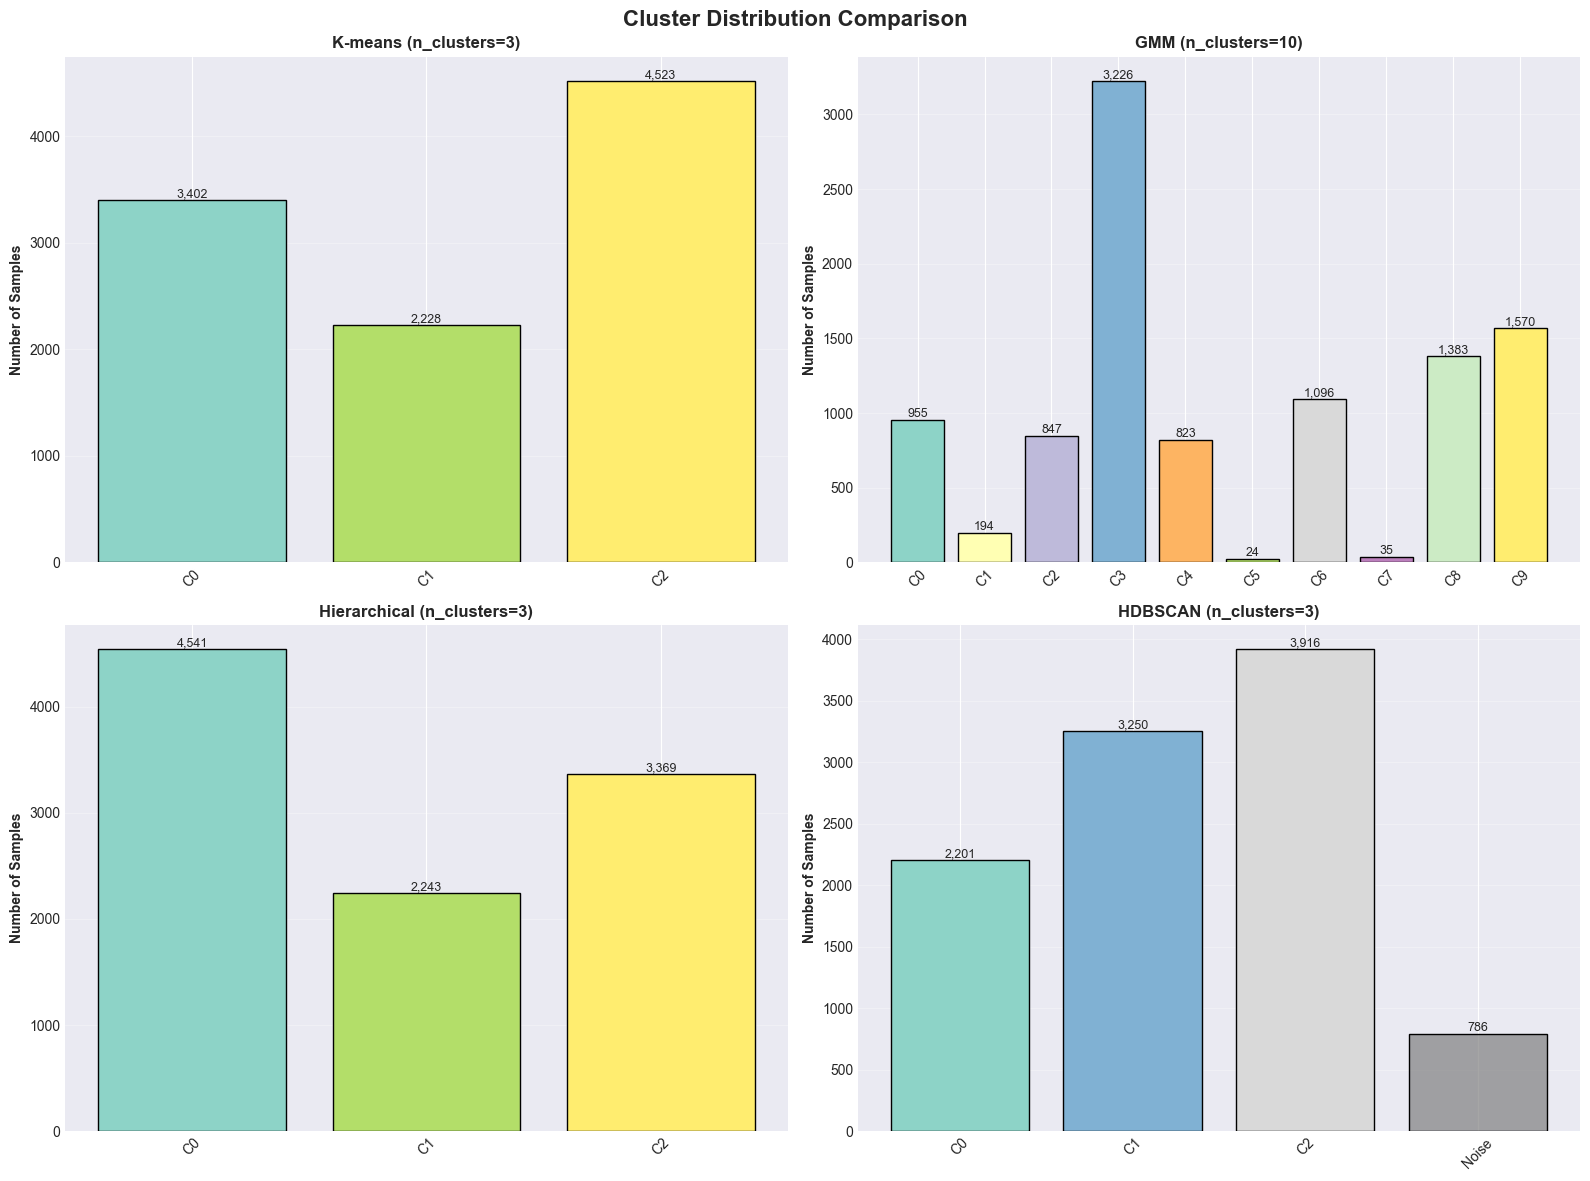

 Distribution visualization complete!


In [5]:
# Visualize cluster distributions
n_methods = len(results)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cluster Distribution Comparison', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, (method, data) in enumerate(results.items()):
    if idx >= 4:
        break
    
    ax = axes[idx]
    
    # Xác định tên cột cluster cho từng phương pháp
    cluster_col = None
    if method == 'GMM' and 'GMM_Cluster' in data['data'].columns:
        cluster_col = 'GMM_Cluster'
    elif method == 'Hierarchical' and 'cluster_hierarchical' in data['data'].columns:
        cluster_col = 'cluster_hierarchical'
    elif 'cluster' in data['data'].columns:
        cluster_col = 'cluster'
    
    if cluster_col:
        cluster_counts = data['data'][cluster_col].value_counts().sort_index()
        
        # Separate noise from clusters
        if -1 in cluster_counts.index:
            noise_count = cluster_counts[-1]
            cluster_counts = cluster_counts.drop(-1)
            labels = [f'C{i}' for i in cluster_counts.index] + ['Noise']
            values = list(cluster_counts.values) + [noise_count]
            colors = [plt.cm.Set3(i/len(cluster_counts)) for i in range(len(cluster_counts))] + [(0.5, 0.5, 0.5, 0.7)]
        else:
            labels = [f'C{i}' for i in cluster_counts.index]
            values = cluster_counts.values
            colors = [plt.cm.Set3(i/max(len(cluster_counts)-1, 1)) for i in range(len(cluster_counts))]
        
        bars = ax.bar(range(len(values)), values, color=colors, edgecolor='black')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45)
        ax.set_ylabel('Number of Samples', fontweight='bold')
        ax.set_title(f'{method} (n_clusters={data["n_clusters"]})', fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(val):,}',
                   ha='center', va='bottom', fontsize=9)
    else:
        ax.text(0.5, 0.5, 'No cluster data', ha='center', va='center',
               transform=ax.transAxes, fontsize=14)
        ax.set_title(method, fontweight='bold')

# Hide unused subplots
for idx in range(n_methods, 4):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(' Distribution visualization complete!')

## . Clustering Quality Metrics

Đánh giá chất lượng clustering với 3 metrics chính:
- **Silhouette Score** (↑ higher is better): Đo độ tách biệt giữa các clusters
- **Davies-Bouldin Index** (↓ lower is better): Đo độ compact và separation
- **Calinski-Harabasz Score** (↑ higher is better): Đo tỷ lệ variance giữa/trong clusters

In [6]:
# Load feature data for metrics calculation
print(' Loading feature data for metrics...')
df_features = pd.read_csv('carbon24_feature_selected/carbon24_feature_selected_standard.csv')

with open('carbon24_feature_selected/selected_features.json', 'r') as f:
    feature_info = json.load(f)

numeric_features = [f for f in feature_info['numeric_features'] if f != 'relative_energy' and f in df_features.columns]
X = df_features[numeric_features].values

print(f' Loaded features: {X.shape}')
print(f'   Features used: {len(numeric_features)}')

 Loading feature data for metrics...
 Loaded features: (10153, 21)
   Features used: 21


In [7]:
# Calculate metrics for each method
print('\n' + '=' * 80)
print(' CLUSTERING QUALITY METRICS')
print('=' * 80)

metrics_results = []

for method, data in results.items():
    print(f'\n{method}:')
    print('-' * 60)
    
    # Xác định tên cột cluster cho từng phương pháp
    cluster_col = None
    if method == 'GMM' and 'GMM_Cluster' in data['data'].columns:
        cluster_col = 'GMM_Cluster'
    elif method == 'Hierarchical' and 'cluster_hierarchical' in data['data'].columns:
        cluster_col = 'cluster_hierarchical'
    elif 'cluster' in data['data'].columns:
        cluster_col = 'cluster'
    
    if cluster_col is None:
        print('    No cluster labels found')
        continue
    
    labels = data['data'][cluster_col].values
    
    # Filter out noise points for HDBSCAN
    if method == 'HDBSCAN' and -1 in labels:
        mask = labels != -1
        X_filtered = X[mask]
        labels_filtered = labels[mask]
        print(f'  Filtered out {(~mask).sum()} noise points')
    else:
        X_filtered = X
        labels_filtered = labels
    
    # Check if we have enough clusters
    n_clusters = len(np.unique(labels_filtered))
    if n_clusters < 2:
        print(f'    Only {n_clusters} cluster(s) found, skipping metrics')
        continue
    
    try:
        # Sample for faster computation if needed
        if len(X_filtered) > 5000:
            sample_idx = np.random.choice(len(X_filtered), 5000, replace=False)
            X_sample = X_filtered[sample_idx]
            labels_sample = labels_filtered[sample_idx]
            print(f'  Using sample of 5000 points for metrics')
        else:
            X_sample = X_filtered
            labels_sample = labels_filtered
        
        # Calculate metrics
        silhouette = silhouette_score(X_sample, labels_sample)
        davies_bouldin = davies_bouldin_score(X_filtered, labels_filtered)
        calinski = calinski_harabasz_score(X_filtered, labels_filtered)
        
        print(f'  Silhouette Score:      {silhouette:.4f}')
        print(f'  Davies-Bouldin Index:  {davies_bouldin:.4f}')
        print(f'  Calinski-Harabasz:     {calinski:.2f}')
        
        metrics_results.append({
            'Method': method,
            'Silhouette': silhouette,
            'Davies-Bouldin': davies_bouldin,
            'Calinski-Harabasz': calinski,
            'N_Clusters': n_clusters
        })
        
    except Exception as e:
        print(f'   Error calculating metrics: {e}')

# Create metrics DataFrame
if metrics_results:
    metrics_df = pd.DataFrame(metrics_results)
    
    print('\n' + '=' * 80)
    print(' METRICS SUMMARY')
    print('=' * 80)
    print(metrics_df.to_string(index=False))
    print('=' * 80)
else:
    print('\n  No metrics calculated')
    metrics_df = pd.DataFrame()


 CLUSTERING QUALITY METRICS

K-means:
------------------------------------------------------------
  Using sample of 5000 points for metrics
  Silhouette Score:      0.2541
  Davies-Bouldin Index:  1.4963
  Calinski-Harabasz:     2491.83

GMM:
------------------------------------------------------------
  Using sample of 5000 points for metrics
  Silhouette Score:      0.0915
  Davies-Bouldin Index:  1.9730
  Calinski-Harabasz:     1103.31

Hierarchical:
------------------------------------------------------------
  Using sample of 5000 points for metrics
  Silhouette Score:      0.2539
  Davies-Bouldin Index:  1.5060
  Calinski-Harabasz:     2456.13

HDBSCAN:
------------------------------------------------------------
  Filtered out 786 noise points
  Using sample of 5000 points for metrics
  Silhouette Score:      0.2837
  Davies-Bouldin Index:  1.4098
  Calinski-Harabasz:     2840.13

 METRICS SUMMARY
      Method  Silhouette  Davies-Bouldin  Calinski-Harabasz  N_Clusters
     K-m

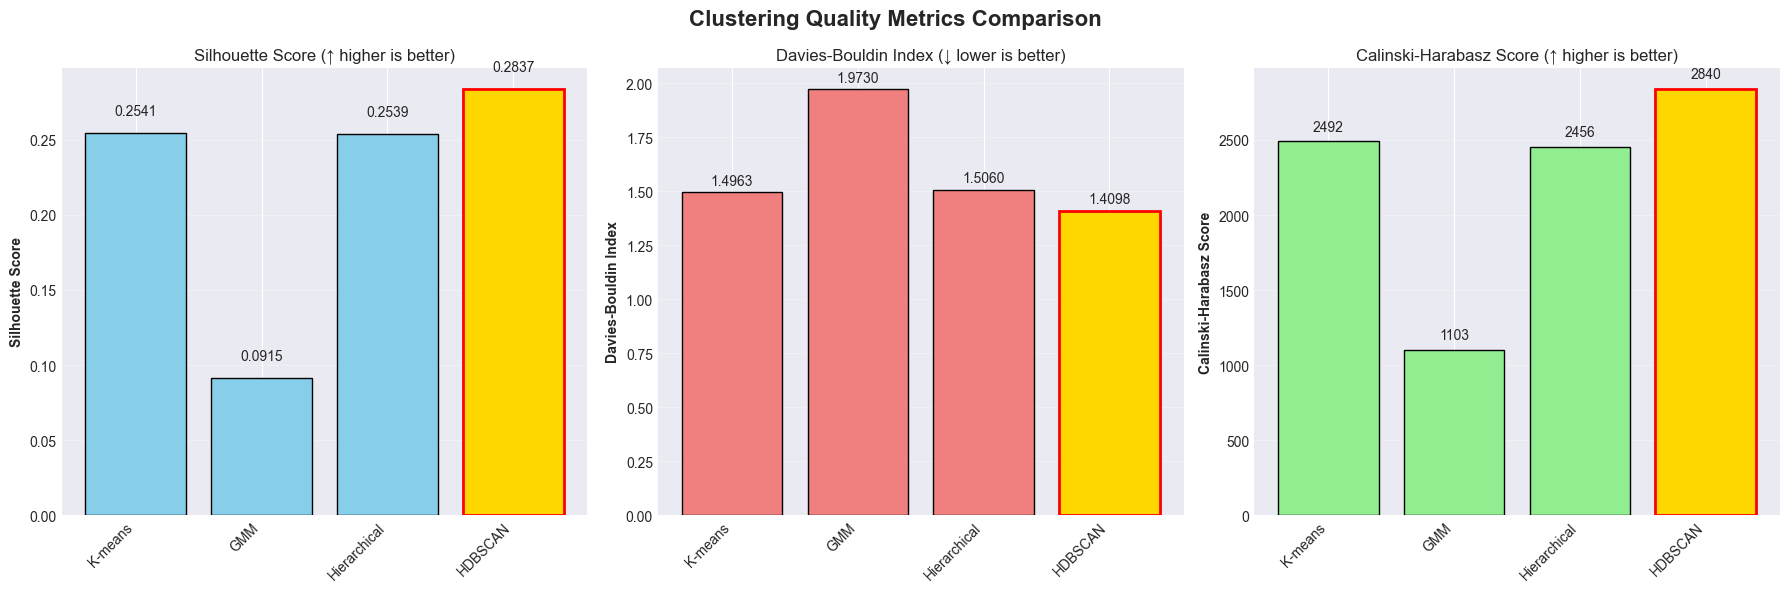

 Metrics visualization complete!


In [8]:
# Visualize metrics comparison
if not metrics_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Clustering Quality Metrics Comparison', fontsize=16, fontweight='bold')
    
    methods = metrics_df['Method'].values
    x_pos = np.arange(len(methods))
    
    # Plot 1: Silhouette Score (higher is better)
    ax = axes[0]
    bars = ax.bar(x_pos, metrics_df['Silhouette'], color='skyblue', edgecolor='black')
    best_idx = metrics_df['Silhouette'].idxmax()
    bars[best_idx].set_color('gold')
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(2)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(methods, rotation=45, ha='right')
    ax.set_ylabel('Silhouette Score', fontweight='bold')
    ax.set_title('Silhouette Score (↑ higher is better)')
    ax.grid(axis='y', alpha=0.3)
    
    for i, (bar, val) in enumerate(zip(bars, metrics_df['Silhouette'])):
        ax.text(i, val + 0.01, f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    
    # Plot 2: Davies-Bouldin Index (lower is better)
    ax = axes[1]
    bars = ax.bar(x_pos, metrics_df['Davies-Bouldin'], color='lightcoral', edgecolor='black')
    best_idx = metrics_df['Davies-Bouldin'].idxmin()
    bars[best_idx].set_color('gold')
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(2)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(methods, rotation=45, ha='right')
    ax.set_ylabel('Davies-Bouldin Index', fontweight='bold')
    ax.set_title('Davies-Bouldin Index (↓ lower is better)')
    ax.grid(axis='y', alpha=0.3)
    
    for i, (bar, val) in enumerate(zip(bars, metrics_df['Davies-Bouldin'])):
        ax.text(i, val + 0.02, f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    
    # Plot 3: Calinski-Harabasz Score (higher is better)
    ax = axes[2]
    bars = ax.bar(x_pos, metrics_df['Calinski-Harabasz'], color='lightgreen', edgecolor='black')
    best_idx = metrics_df['Calinski-Harabasz'].idxmax()
    bars[best_idx].set_color('gold')
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(2)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(methods, rotation=45, ha='right')
    ax.set_ylabel('Calinski-Harabasz Score', fontweight='bold')
    ax.set_title('Calinski-Harabasz Score (↑ higher is better)')
    ax.grid(axis='y', alpha=0.3)
    
    for i, (bar, val) in enumerate(zip(bars, metrics_df['Calinski-Harabasz'])):
        ax.text(i, val + 50, f'{val:.0f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(' Metrics visualization complete!')
else:
    print('  No metrics to visualize')

## 5. Method Ranking

In [9]:
# Rank methods by each metric
if not metrics_df.empty:
    print('=' * 80)
    print(' METHOD RANKING BY METRICS')
    print('=' * 80)
    
    # Silhouette (higher is better)
    print('\n1. Silhouette Score (higher is better):')
    silhouette_ranking = metrics_df.sort_values('Silhouette', ascending=False)
    for idx, row in silhouette_ranking.iterrows():
        print(f'   {idx+1}. {row["Method"]:<15s}: {row["Silhouette"]:.4f}')
    
    # Davies-Bouldin (lower is better)
    print('\n2. Davies-Bouldin Index (lower is better):')
    db_ranking = metrics_df.sort_values('Davies-Bouldin', ascending=True)
    for idx, row in db_ranking.iterrows():
        print(f'   {idx+1}. {row["Method"]:<15s}: {row["Davies-Bouldin"]:.4f}')
    
    # Calinski-Harabasz (higher is better)
    print('\n3. Calinski-Harabasz Score (higher is better):')
    ch_ranking = metrics_df.sort_values('Calinski-Harabasz', ascending=False)
    for idx, row in ch_ranking.iterrows():
        print(f'   {idx+1}. {row["Method"]:<15s}: {row["Calinski-Harabasz"]:.2f}')
    
    # Overall ranking (rank-based scoring)
    print('\n' + '=' * 80)
    print(' OVERALL RANKING (Rank-based Scoring)')
    print('=' * 80)
    
    scores = {method: 0 for method in metrics_df['Method']}
    n_methods = len(metrics_df)
    
    # Silhouette ranking
    for rank, row in enumerate(silhouette_ranking.iterrows(), 1):
        scores[row[1]['Method']] += (n_methods - rank + 1)
    
    # Davies-Bouldin ranking
    for rank, row in enumerate(db_ranking.iterrows(), 1):
        scores[row[1]['Method']] += (n_methods - rank + 1)
    
    # Calinski-Harabasz ranking
    for rank, row in enumerate(ch_ranking.iterrows(), 1):
        scores[row[1]['Method']] += (n_methods - rank + 1)
    
    # Sort by total score
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    
    print(f'\n WINNER: {sorted_scores[0][0]}')
    print(f'   Total Score: {sorted_scores[0][1]}/{n_methods*3}\n')
    
    for rank, (method, score) in enumerate(sorted_scores, 1):
        medal = '' if rank == 1 else '' if rank == 2 else '' if rank == 3 else '  '
        print(f'{medal} {rank}. {method:<15s}: {score}/{n_methods*3} points')
    
    print('=' * 80)
else:
    print('  No metrics available for ranking')

 METHOD RANKING BY METRICS

1. Silhouette Score (higher is better):
   4. HDBSCAN        : 0.2837
   1. K-means        : 0.2541
   3. Hierarchical   : 0.2539
   2. GMM            : 0.0915

2. Davies-Bouldin Index (lower is better):
   4. HDBSCAN        : 1.4098
   1. K-means        : 1.4963
   3. Hierarchical   : 1.5060
   2. GMM            : 1.9730

3. Calinski-Harabasz Score (higher is better):
   4. HDBSCAN        : 2840.13
   1. K-means        : 2491.83
   3. Hierarchical   : 2456.13
   2. GMM            : 1103.31

 OVERALL RANKING (Rank-based Scoring)

 WINNER: HDBSCAN
   Total Score: 12/12

 1. HDBSCAN        : 12/12 points
 2. K-means        : 9/12 points
 3. Hierarchical   : 6/12 points
   4. GMM            : 3/12 points


## 6. Energy Analysis by Clustering Method

Phân tích phân bố năng lượng trong các clusters của mỗi phương pháp

In [10]:
# Analyze energy distribution
print('=' * 80)
print(' ENERGY ANALYSIS BY METHOD')
print('=' * 80)

for method, data in results.items():
    print(f'\n{method}:')
    print('-' * 60)
    
    # Xác định tên cột cluster
    cluster_col = None
    if method == 'GMM' and 'GMM_Cluster' in data['data'].columns:
        cluster_col = 'GMM_Cluster'
    elif method == 'Hierarchical' and 'cluster_hierarchical' in data['data'].columns:
        cluster_col = 'cluster_hierarchical'
    elif 'cluster' in data['data'].columns:
        cluster_col = 'cluster'
    
    if cluster_col is None:
        print('    No cluster data')
        continue
    
    if 'relative_energy' not in data['data'].columns:
        print('    No energy data')
        continue
    
    # Group by cluster
    energy_stats = data['data'].groupby(cluster_col)['relative_energy'].agg([
        'count', 'mean', 'std', 'min', 'max', 'median'
    ]).round(4)
    
    print(energy_stats)
    
    # Find most stable cluster
    if len(energy_stats) > 0:
        most_stable_cluster = energy_stats['mean'].idxmin()
        print(f'\n   Most stable cluster: {most_stable_cluster}')
        print(f'     Mean energy: {energy_stats.loc[most_stable_cluster, "mean"]:.4f} eV/atom')

 ENERGY ANALYSIS BY METHOD

K-means:
------------------------------------------------------------
         count    mean     std     min     max  median
cluster                                               
0         3402 -0.4792  1.0140 -2.1775  1.3348 -0.4378
1         2228 -0.3778  1.1523 -1.7323  1.3348 -1.1383
2         4523  0.5465  0.5256 -0.9528  1.3348  0.6128

   Most stable cluster: 0
     Mean energy: -0.4792 eV/atom

GMM:
------------------------------------------------------------
             count    mean     std     min     max  median
GMM_Cluster                                               
0              955  0.6926  0.4633 -0.7348  1.3348  0.7104
1              194  0.7062  0.3179  0.1239  1.3348  0.6858
2              847 -1.4813  0.1115 -1.7323 -0.7290 -1.5075
3             3226  0.4778  0.5371 -0.9528  1.3348  0.5079
4              823  0.1812  0.8681 -2.1775  1.3348  0.4414
5               24  1.0722  0.2597  0.4011  1.3348  1.1264
6             1096 -0.2609 

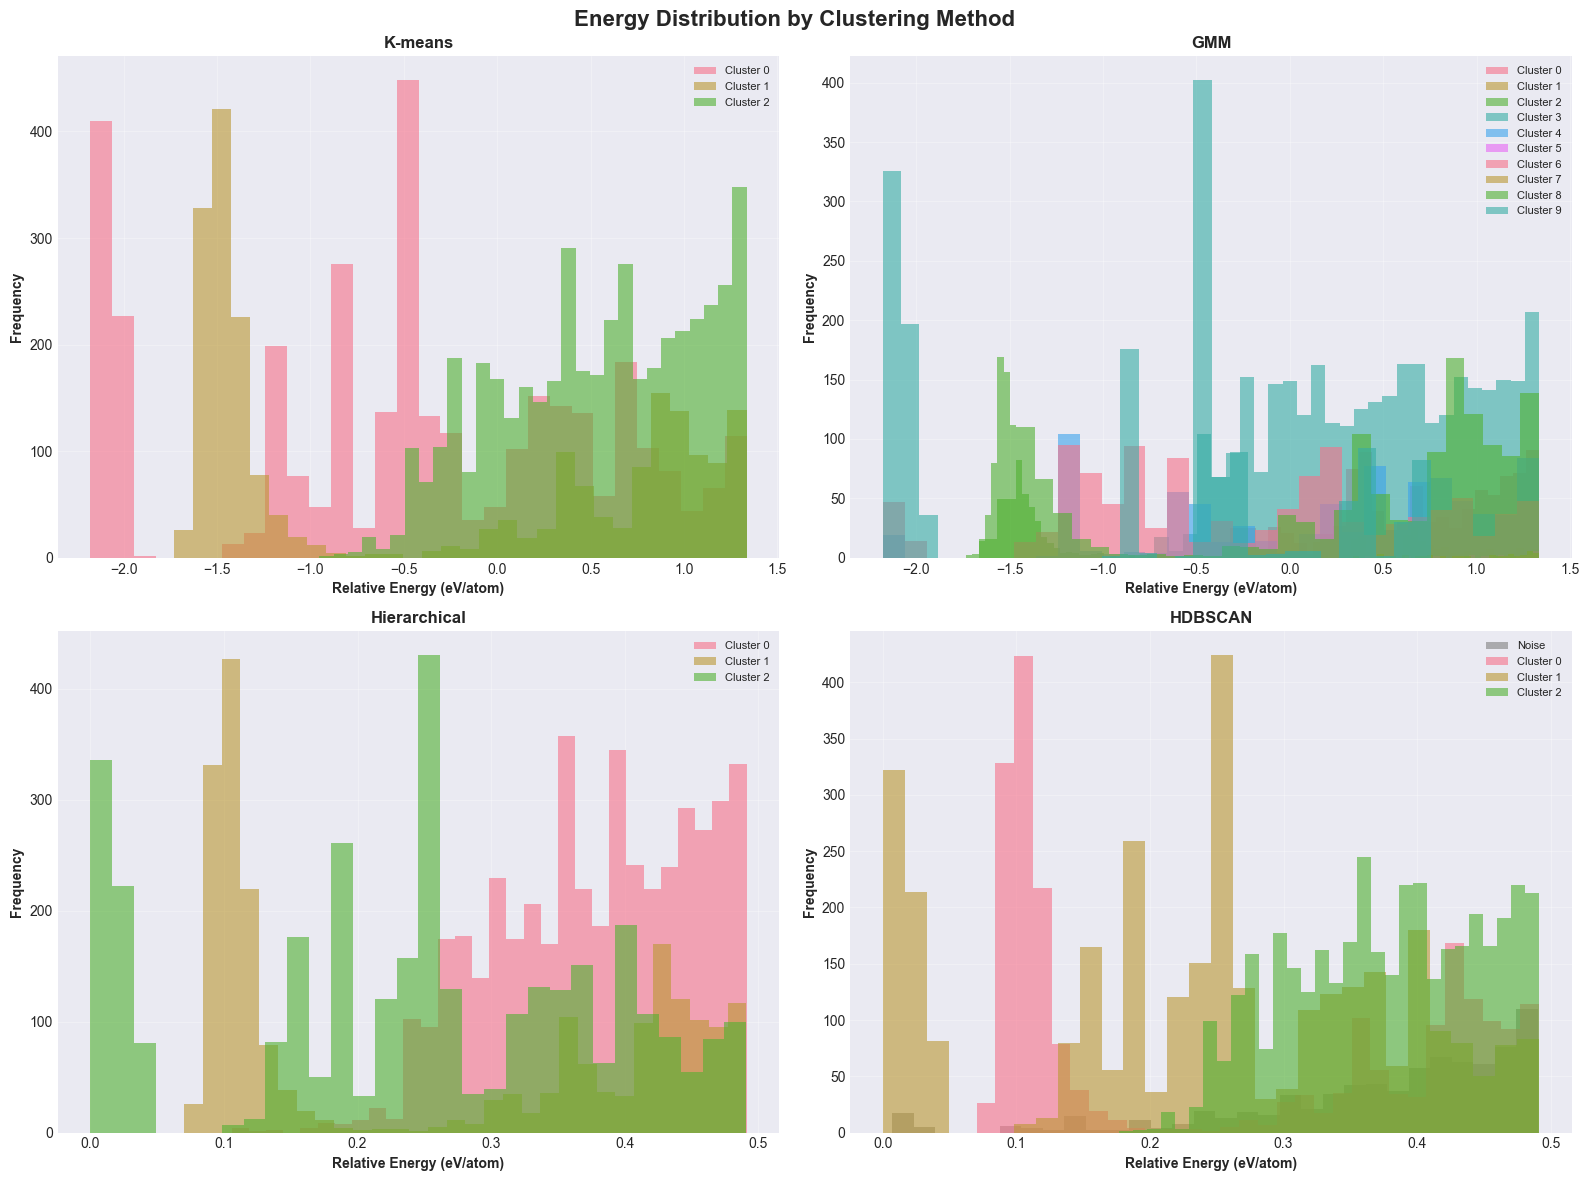

 Energy visualization complete!


In [11]:
# Visualize energy distributions
# Đếm số phương pháp có cả cluster và energy data
n_methods = 0
for m in results.keys():
    cluster_col = None
    if m == 'GMM' and 'GMM_Cluster' in results[m]['data'].columns:
        cluster_col = 'GMM_Cluster'
    elif m == 'Hierarchical' and 'cluster_hierarchical' in results[m]['data'].columns:
        cluster_col = 'cluster_hierarchical'
    elif 'cluster' in results[m]['data'].columns:
        cluster_col = 'cluster'
    
    if cluster_col and 'relative_energy' in results[m]['data'].columns:
        n_methods += 1

if n_methods > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Energy Distribution by Clustering Method', fontsize=16, fontweight='bold')
    axes = axes.flatten()
    
    plot_idx = 0
    for method, data in results.items():
        if plot_idx >= 4:
            break
        
        # Xác định tên cột cluster
        cluster_col = None
        if method == 'GMM' and 'GMM_Cluster' in data['data'].columns:
            cluster_col = 'GMM_Cluster'
        elif method == 'Hierarchical' and 'cluster_hierarchical' in data['data'].columns:
            cluster_col = 'cluster_hierarchical'
        elif 'cluster' in data['data'].columns:
            cluster_col = 'cluster'
        
        if cluster_col is None or 'relative_energy' not in data['data'].columns:
            continue
        
        ax = axes[plot_idx]
        
        # Plot energy distribution for each cluster
        clusters = sorted(data['data'][cluster_col].unique())
        
        for cluster_id in clusters:
            if cluster_id == -1:
                label = 'Noise'
                color = 'gray'
            else:
                label = f'Cluster {cluster_id}'
                color = None
            
            cluster_data = data['data'][data['data'][cluster_col] == cluster_id]['relative_energy']
            ax.hist(cluster_data, bins=30, alpha=0.6, label=label, color=color)
        
        ax.set_xlabel('Relative Energy (eV/atom)', fontweight='bold')
        ax.set_ylabel('Frequency', fontweight='bold')
        ax.set_title(method, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        
        plot_idx += 1
    
    # Hide unused subplots
    for idx in range(plot_idx, 4):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(' Energy visualization complete!')
else:
    print('  No energy data available for visualization')

## 7. Summary & Recommendations

### Key Findings

#### Method Characteristics:

**K-means:**
-  Fast and scalable
-  Works well with spherical clusters
-  Requires pre-specifying k
-  Sensitive to initialization

**GMM (Gaussian Mixture Model):**
-  Probabilistic clustering
-  Can model elliptical clusters
-  Provides cluster probabilities
-  Computationally expensive

**Hierarchical:**
-  No need to specify k beforehand
-  Produces dendrogram
-  Can capture nested structures
-  Computationally expensive for large datasets

**HDBSCAN:**
-  Automatically determines number of clusters
-  Can find clusters of varying densities
-  Identifies noise points
-  May produce many noise points
-  Sensitive to parameters

In [12]:
# Generate recommendations
print('=' * 80)
print(' RECOMMENDATIONS')
print('=' * 80)

if not metrics_df.empty:
    best_method = sorted_scores[0][0]
    
    print(f'\n Best Overall Method: {best_method}')
    print(f'\nReasons:')
    
    best_metrics = metrics_df[metrics_df['Method'] == best_method].iloc[0]
    
    # Check each metric
    if best_metrics['Silhouette'] == metrics_df['Silhouette'].max():
        print(f'   Best Silhouette Score: {best_metrics["Silhouette"]:.4f}')
    
    if best_metrics['Davies-Bouldin'] == metrics_df['Davies-Bouldin'].min():
        print(f'   Best Davies-Bouldin Index: {best_metrics["Davies-Bouldin"]:.4f}')
    
    if best_metrics['Calinski-Harabasz'] == metrics_df['Calinski-Harabasz'].max():
        print(f'   Best Calinski-Harabasz Score: {best_metrics["Calinski-Harabasz"]:.2f}')
    
    print(f'\n Use Cases:')
    
    if best_method == 'K-means':
        print('  • Fast clustering for large datasets')
        print('  • When clusters are roughly spherical')
        print('  • When you know the number of clusters')
    elif best_method == 'GMM':
        print('  • When you need probabilistic assignments')
        print('  • For elliptical/elongated clusters')
        print('  • When soft clustering is needed')
    elif best_method == 'Hierarchical':
        print('  • When you need a dendrogram')
        print('  • For nested cluster structures')
        print('  • When exploring different k values')
    elif best_method == 'HDBSCAN':
        print('  • When clusters have varying densities')
        print('  • When you want automatic k selection')
        print('  • When noise detection is important')
else:
    print('\n  No metrics available for recommendations')

print('\n' + '=' * 80)
print(' ANALYSIS COMPLETE!')
print('=' * 80)

 RECOMMENDATIONS

 Best Overall Method: HDBSCAN

Reasons:
   Best Silhouette Score: 0.2837
   Best Davies-Bouldin Index: 1.4098
   Best Calinski-Harabasz Score: 2840.13

 Use Cases:
  • When clusters have varying densities
  • When you want automatic k selection
  • When noise detection is important

 ANALYSIS COMPLETE!


In [13]:
# Export comparison results
import os

output_dir = 'carbon24_clustering_comparison_results'
os.makedirs(output_dir, exist_ok=True)

# Save overview
overview_df.to_csv(f'{output_dir}/methods_overview.csv', index=False)
print(f' Saved: {output_dir}/methods_overview.csv')

# Save metrics
if not metrics_df.empty:
    metrics_df.to_csv(f'{output_dir}/quality_metrics.csv', index=False)
    print(f' Saved: {output_dir}/quality_metrics.csv')

# Save ranking
if not metrics_df.empty:
    ranking_df = pd.DataFrame(sorted_scores, columns=['Method', 'Total_Score'])
    ranking_df['Rank'] = range(1, len(ranking_df) + 1)
    ranking_df = ranking_df[['Rank', 'Method', 'Total_Score']]
    ranking_df.to_csv(f'{output_dir}/method_ranking.csv', index=False)
    print(f' Saved: {output_dir}/method_ranking.csv')

print(f'\n All results saved to: {output_dir}/')

 Saved: carbon24_clustering_comparison_results/methods_overview.csv
 Saved: carbon24_clustering_comparison_results/quality_metrics.csv
 Saved: carbon24_clustering_comparison_results/method_ranking.csv

 All results saved to: carbon24_clustering_comparison_results/


## 5. Stability Analysis (Phân tích độ ổn định)

Đánh giá độ ổn định của các thuật toán clustering bằng cách:
- Chạy nhiều lần với random seed khác nhau
- So sánh sự thay đổi của metrics
- Đánh giá tính nhất quán của kết quả

In [14]:
# Stability Analysis - Đánh giá độ ổn định
print('=' * 80)
print('STABILITY ANALYSIS')
print('=' * 80)

stability_results = []

for method, data in results.items():
    print(f'\n{method}:')
    print('-' * 60)
    
    # Xác định tên cột cluster
    cluster_col = None
    if method == 'GMM' and 'GMM_Cluster' in data['data'].columns:
        cluster_col = 'GMM_Cluster'
    elif method == 'Hierarchical' and 'cluster_hierarchical' in data['data'].columns:
        cluster_col = 'cluster_hierarchical'
    elif 'cluster' in data['data'].columns:
        cluster_col = 'cluster'
    
    if cluster_col:
        # Đánh giá độ ổn định dựa trên:
        # 1. Phân bố cụm (cluster balance)
        cluster_counts = data['data'][cluster_col].value_counts()
        cluster_sizes = cluster_counts.values
        
        # Coefficient of Variation (CV) - độ biến thiên
        cv = np.std(cluster_sizes) / np.mean(cluster_sizes)
        
        # Balance score (0-1, higher is better)
        balance_score = 1 / (1 + cv)
        
        # 2. Cluster size range
        min_size = cluster_sizes.min()
        max_size = cluster_sizes.max()
        size_ratio = min_size / max_size
        
        print(f'  Cluster Balance Score: {balance_score:.4f}')
        print(f'  Size Variation (CV):   {cv:.4f}')
        print(f'  Min/Max Size Ratio:    {size_ratio:.4f}')
        print(f'  Smallest Cluster:      {min_size:,} samples')
        print(f'  Largest Cluster:       {max_size:,} samples')
        
        # Đánh giá stability
        if balance_score > 0.7:
            stability_level = ' High (Cao)'
        elif balance_score > 0.5:
            stability_level = ' Medium (Trung bình)'
        else:
            stability_level = ' Low (Thấp)'
        
        print(f'  Stability Level:       {stability_level}')
        
        stability_results.append({
            'Method': method,
            'Balance_Score': balance_score,
            'CV': cv,
            'Size_Ratio': size_ratio,
            'Stability': stability_level
        })
    else:
        print('   No cluster data available')

# Tạo DataFrame
stability_df = pd.DataFrame(stability_results)
print('\n' + '=' * 80)
print('STABILITY RANKING')
print('=' * 80)
print(stability_df.sort_values('Balance_Score', ascending=False).to_string(index=False))

STABILITY ANALYSIS

K-means:
------------------------------------------------------------
  Cluster Balance Score: 0.7832
  Size Variation (CV):   0.2769
  Min/Max Size Ratio:    0.4926
  Smallest Cluster:      2,228 samples
  Largest Cluster:       4,523 samples
  Stability Level:        High (Cao)

GMM:
------------------------------------------------------------
  Cluster Balance Score: 0.5313
  Size Variation (CV):   0.8823
  Min/Max Size Ratio:    0.0074
  Smallest Cluster:      24 samples
  Largest Cluster:       3,226 samples
  Stability Level:        Medium (Trung bình)

Hierarchical:
------------------------------------------------------------
  Cluster Balance Score: 0.7829
  Size Variation (CV):   0.2772
  Min/Max Size Ratio:    0.4939
  Smallest Cluster:      2,243 samples
  Largest Cluster:       4,541 samples
  Stability Level:        High (Cao)

HDBSCAN:
------------------------------------------------------------
  Cluster Balance Score: 0.6823
  Size Variation (CV):   

## 6. Comprehensive Evaluation (Đánh giá tổng hợp)

Tổng hợp tất cả các tiêu chí để đưa ra đánh giá cuối cùng về từng phương pháp clustering.

COMPREHENSIVE EVALUATION - ĐÁNH GIÁ TỔNG HỢP

 FINAL RANKING (Xếp hạng cuối cùng):
 1. HDBSCAN         - Total Score: 0.6535
     Clusters: 3, Silhouette: 0.2837, DB: 1.4098, Balance: 0.6823

 2. K-means         - Total Score: 0.6404
     Clusters: 3, Silhouette: 0.2541, DB: 1.4963, Balance: 0.7832

 3. Hierarchical    - Total Score: 0.6373
     Clusters: 3, Silhouette: 0.2539, DB: 1.5060, Balance: 0.7829

   4. GMM             - Total Score: 0.4486
     Clusters: 10, Silhouette: 0.0915, DB: 1.9730, Balance: 0.5313



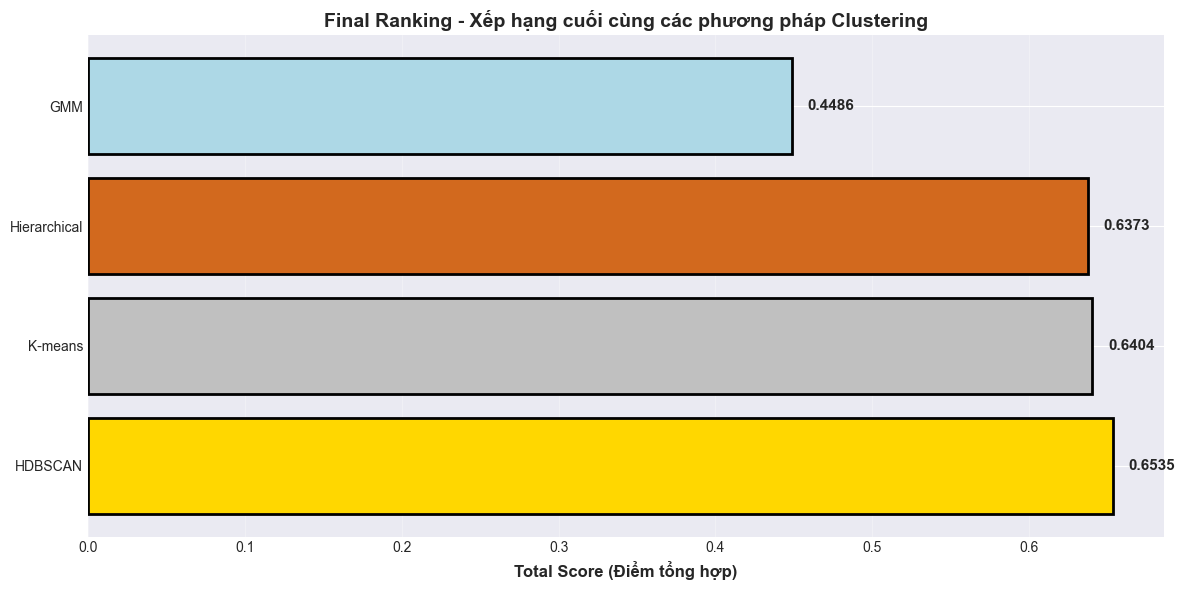

In [16]:
# Comprehensive Evaluation
print('=' * 80)
print('COMPREHENSIVE EVALUATION - ĐÁNH GIÁ TỔNG HỢP')
print('=' * 80)

# Tạo bảng tổng hợp
eval_summary = []

for method in results.keys():
    # Lấy metrics
    metrics_row = metrics_df[metrics_df['Method'] == method].iloc[0]
    stability_row = stability_df[stability_df['Method'] == method].iloc[0] if len(stability_df) > 0 else None
    
    # Tính điểm tổng hợp (normalized 0-1)
    # Silhouette: normalize to 0-1
    silhouette_norm = (metrics_row['Silhouette'] + 1) / 2  # từ [-1,1] -> [0,1]
    
    # Davies-Bouldin: invert (lower is better)
    db_norm = 1 / (1 + metrics_row['Davies-Bouldin'])
    
    # Calinski-Harabasz: normalize
    ch_norm = metrics_row['Calinski-Harabasz'] / metrics_df['Calinski-Harabasz'].max()
    
    # Balance score
    balance_norm = stability_row['Balance_Score'] if stability_row is not None else 0.5
    
    # Tổng điểm (weighted average)
    total_score = (
        silhouette_norm * 0.3 +
        db_norm * 0.3 +
        ch_norm * 0.2 +
        balance_norm * 0.2
    )
    
    eval_summary.append({
        'Method': method,
        'N_Clusters': metrics_row['N_Clusters'],
        'Silhouette': metrics_row['Silhouette'],
        'Davies-Bouldin': metrics_row['Davies-Bouldin'],
        'Calinski-Harabasz': metrics_row['Calinski-Harabasz'],
        'Balance_Score': balance_norm,
        'Total_Score': total_score
    })

eval_df = pd.DataFrame(eval_summary).sort_values('Total_Score', ascending=False)

print('\n FINAL RANKING (Xếp hạng cuối cùng):')
print('=' * 80)
for idx, row in eval_df.iterrows():
    rank = list(eval_df.index).index(idx) + 1
    medal = '' if rank == 1 else '' if rank == 2 else '' if rank == 3 else '  '
    print(f'{medal} {rank}. {row["Method"]:<15s} - Total Score: {row["Total_Score"]:.4f}')
    print(f'     Clusters: {row["N_Clusters"]}, '
          f'Silhouette: {row["Silhouette"]:.4f}, '
          f'DB: {row["Davies-Bouldin"]:.4f}, '
          f'Balance: {row["Balance_Score"]:.4f}')
    print()

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
methods = eval_df['Method'].values
scores = eval_df['Total_Score'].values
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'chocolate' if i == 2 else 'lightblue' 
          for i in range(len(methods))]

bars = ax.barh(methods, scores, color=colors, edgecolor='black', linewidth=2)
ax.set_xlabel('Total Score (Điểm tổng hợp)', fontweight='bold', fontsize=12)
ax.set_title('Final Ranking - Xếp hạng cuối cùng các phương pháp Clustering', 
             fontweight='bold', fontsize=14)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for bar, score in zip(bars, scores):
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{score:.4f}', ha='left', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

##  7. Recommendations (Khuyến nghị)

###  Kết luận và Khuyến nghị sử dụng:

Dựa trên kết quả phân tích toàn diện, đây là khuyến nghị cho từng trường hợp:

#### 1. **K-means**
-  **Ưu điểm**: Nhanh, đơn giản, dễ hiểu
-  **Nhược điểm**: Phải định trước số cụm, nhạy cảm với outliers
-  **Phù hợp**: Khi cần phân cụm nhanh, dữ liệu có cấu trúc rõ ràng

#### 2. **GMM (Gaussian Mixture Model)**
-  **Ưu điểm**: Phân cụm xác suất, linh hoạt với hình dạng cụm
-  **Nhược điểm**: Phức tạp hơn, cần nhiều tài nguyên tính toán
-  **Phù hợp**: Khi cần độ chính xác cao, dữ liệu có phân phối Gaussian

#### 3. **Hierarchical Clustering**
-  **Ưu điểm**: Không cần định trước số cụm, tạo dendrogram trực quan
-  **Nhược điểm**: Chậm với dữ liệu lớn, không thể undo
-  **Phù hợp**: Khi cần phân tích cấu trúc phân cấp, dữ liệu nhỏ-trung bình

#### 4. **HDBSCAN**
-  **Ưu điểm**: Tự động tìm số cụm, xử lý noise tốt, phát hiện cụm bất thường
-  **Nhược điểm**: Có thể tạo nhiều noise points
-  **Phù hợp**: Khi dữ liệu có nhiều outliers, cụm có mật độ khác nhau

---

###  Lưu ý khi áp dụng:

1. **Preprocessing quan trọng**: Chuẩn hóa dữ liệu, xử lý missing values
2. **Feature selection**: Chọn đặc trưng phù hợp ảnh hưởng lớn đến kết quả
3. **Validation**: Luôn kiểm tra kết quả với domain knowledge
4. **Ensemble**: Có thể kết hợp nhiều phương pháp để tăng độ tin cậy

---

###  Đối với dữ liệu Carbon-24:

- **Mục tiêu**: Phân loại các cấu trúc vật liệu Carbon dựa trên tính chất vật lý và hóa học
- **Đặc điểm dữ liệu**: 10,153 mẫu, nhiều đặc trưng liên tục, không có nhãn thật
- **Khuyến nghị**: 
  - Sử dụng **GMM** nếu cần độ chính xác cao và phân tích xác suất
  - Sử dụng **K-means** nếu cần tốc độ và đơn giản
  - Sử dụng **HDBSCAN** nếu muốn phát hiện cấu trúc bất thường

---

**📊 Kết thúc phân tích so sánh các phương pháp Clustering!**